In [104]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,KFold

In [105]:
np.random.seed(0)

In [106]:
dogs_whisker_length=np.random.normal(loc=5,scale=1,size=10)
dogs_ear_flappiness_index=np.random.normal(loc=8,scale=1,size=10)

In [107]:
cats_whisker_length=np.random.normal(loc=8,scale=1,size=10)
cats_ear_flappiness_index=np.random.normal(loc=5,scale=1,size=10)

In [108]:
dogs_data=np.vstack((dogs_whisker_length, dogs_ear_flappiness_index)).T
cats_data=np.vstack((cats_whisker_length, cats_ear_flappiness_index)).T
data=np.vstack((dogs_data,cats_data))
labels=np.hstack((np.zeros(len(dogs_data)),np.ones(len(cats_data))))


In [109]:
x_train, x_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

In [110]:
x_test

array([[6.76405235, 8.14404357],
       [7.81281615, 6.20237985],
       [6.54563433, 5.15634897],
       [5.40015721, 9.45427351]])

In [111]:
Y_test

array([0., 1., 1., 0.])

In [112]:
y_train

array([0., 0., 1., 0., 1., 1., 1., 0., 0., 1., 0., 1., 0., 1., 1., 0.])

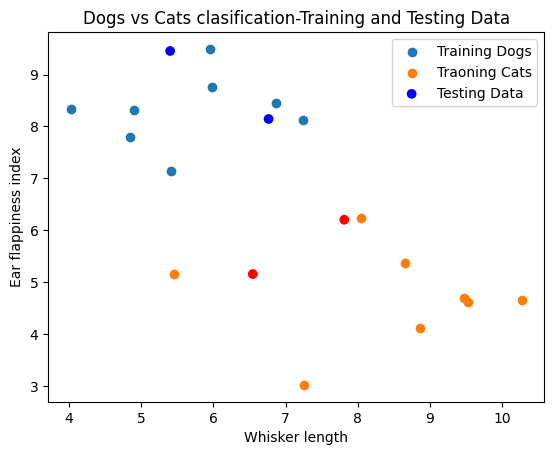

In [113]:
plt.scatter(x_train[y_train==0][:,0],x_train[y_train==0][:,1],label='Training Dogs')
plt.scatter(x_train[y_train==1][:,0],x_train[y_train==1][:,1],label='Traoning Cats')
plt.scatter(x_test[:,0],x_test[:,1],c=Y_test,cmap='bwr', label='Testing Data')
plt.xlabel('Whisker length')
plt.ylabel('Ear flappiness index')
plt.title('Dogs vs Cats clasification-Training and Testing Data')
plt.legend()
plt.show()

In [114]:


def random_linear_classifier(data_dogs, data_cats, k, d):
    # d = number of features (dimension)
    
    best_error = float("inf")
    best_theta = None
    best_theta0 = None

    for _ in range(k):
        # Generate random parameters
        theta = np.random.normal(size=d)
        theta0 = np.random.normal()

        # Compute classification error
        error = compute_error(data_dogs, data_cats, theta, theta0)

        # Keep the best classifier found so far
        if error < best_error:
            best_error = error
            best_theta = theta
            best_theta0 = theta0

    return best_theta0, best_theta

In [115]:
def compute_error(data_dogs, data_cats, theta, theta0):
    error = 0

    for x_dogs in data_dogs:
        if np.dot(theta, x_dogs) + theta0 <= 0:
            error += 1

    for x_cats in data_cats:
        if np.dot(theta, x_cats) + theta0 > 0:
            error += 1

    return error

In [116]:
d=2
k=200
best_theta0_train,best_theta_train= random_linear_classifier(x_train[y_train==0],x_train[y_train==1],k,d)

In [117]:
x_vals_train =np.linspace(2,10,100)
y_vals_train=(-best_theta_train[0]/best_theta_train[1])*x_vals_train-(best_theta0_train/best_theta_train[1])

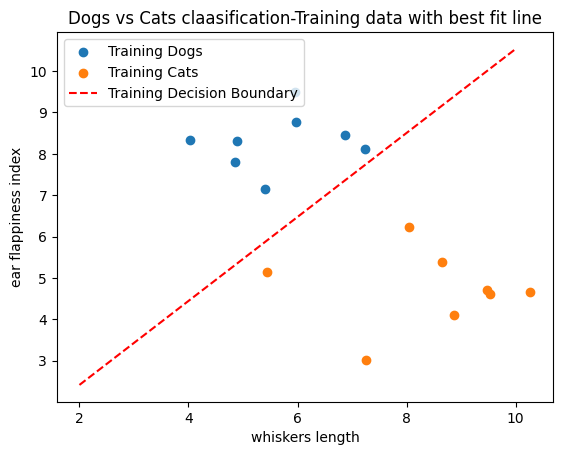

In [118]:
plt.scatter(x_train[y_train==0][:,0],x_train[y_train==0][:,1],label='Training Dogs')
plt.scatter(x_train[y_train==1][:,0],x_train[y_train==1][:,1],label='Training Cats')
plt.plot(x_vals_train, y_vals_train, color= 'red', linestyle='--', label= 'Training Decision Boundary')
plt.xlabel('whiskers length')
plt.ylabel('ear flappiness index')
plt.title('Dogs vs Cats claasification-Training data with best fit line')
plt.legend()
plt.show()

In [119]:
train_error=compute_error(x_test[Y_test==0],x_test[Y_test==1],best_theta_train,best_theta0_train )

In [120]:
print(f"training error:{train_error}")

training error:0


In [121]:
test_error=compute_error(x_test[Y_test==0],x_test[Y_test==1],best_theta_train,best_theta0_train)

In [122]:
print(f"testing error:{test_error}")

testing error:0


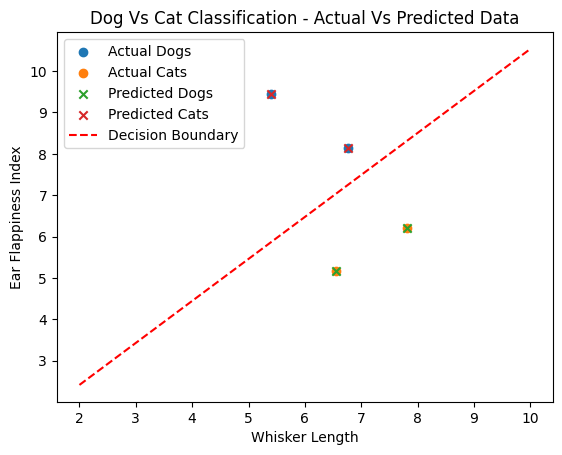

In [ ]:
# Plot actual test data
plt.scatter(x_test[y_test==0][:,0], x_test[y_test==0][:,1], label='Actual Dogs')
plt.scatter(x_test[y_test==1][:,0], x_test[y_test==1][:,1], label='Actual Cats')

# Predict test data points using decision boundary
predicted_labels = np.zeros_like(y_test)
for i, x_point in enumerate(x_test):
    if np.dot(best_theta_train, x_point) + best_theta0_train > 0:
 predicted_labels[i] = 1

# Plot predicted data points
plt.scatter(x_test[predicted_labels==0][:,0], x_test[predicted_labels==0][:,1], marker='x', label='Predicted Dogs')
plt.scatter(x_test[predicted_labels==1][:,0], x_test[predicted_labels==1][:,1], marker='x', label='Predicted Cats')

# Plot decision boundary
plt.plot(x_vals_train, y_vals_train, color='red', linestyle='--', label='Decision Boundary')
plt.xlabel('Whisker Length')
plt.ylabel('Ear Flappiness Index')
plt.title('Dog Vs Cat Classification - Actual Vs Predicted Data')
plt.legend()
plt.show()

In [124]:
#define function for kfold cross validation 
def cross_validate(data_dogs,data_cats,k_values,d,n_split=5):
    kf=KFold(n_splits=n_splits, shuffle=True,random_state=42)
    avg_errors=[]

    for k in k_values:
       errors=[]

       for train_index, val_index in kf.split(data_dogs):
           x_train_fold=np.vstack((dogs_data[train_index],cats_data[train_index]))
           y_train_fold=np.hstack((np.zeros(len(train_index)), np.ones(len(train_index))))

           best_theta_fold,best_theta0_train= random_linear_classifier(x_train_fold[y_train_fold==0],x_train_fold[y_train_fold==1],k,d)

           errors.append(compute_error(x_val_fold[Y_val_fold==0],x_val_fold[Y_val_fold==1],best_theta_fold,best_theta0_fold))
           avg_errors.append(np.mean(errors))
           best_k=k_values(np.argmin(avg_errors))
           return best_k
       
       #Define k values to try
       k_values(1,10,50,100,200,350)
       best_k=cross_validate(dogs_data,cats_data,k_values,d=2)
       
       print(f"best value of k:{best_k}")


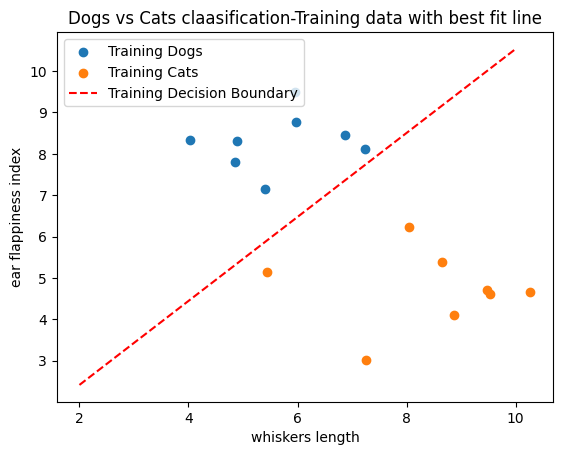

In [125]:
plt.scatter(x_train[y_train==0][:,0],x_train[y_train==0][:,1],label='Training Dogs')
plt.scatter(x_train[y_train==1][:,0],x_train[y_train==1][:,1],label='Training Cats')
plt.plot(x_vals_train, y_vals_train, color= 'red', linestyle='--', label= 'Training Decision Boundary')
plt.xlabel('whiskers length')
plt.ylabel('ear flappiness index')
plt.title('Dogs vs Cats claasification-Training data with best fit line')
plt.legend()
plt.show()